# 🏈🏉NFL BDB 2024 - Detailed EDA and Animations🕡🕤

## Sampled from Notebook
- https://www.kaggle.com/code/gvyshnya/nfl-bdb-2024-detailed-eda-and-animations/

## Setup
- Download the dataset from Kaggle: https://www.kaggle.com/competitions/nfl-big-data-bowl-2024/data
- Place the dataset in a directory, e.g., `~/.kaggle/input`
- For VSCode install extensions : VSCode animations, APC Customize UI ++, Jupyter Notebook Renderers

In [ ]:
from IPython.display import HTML, Markdown
import time

handle = display(HTML("""<marquee>🏈🏈🏈</marquee>"""), display_id='html_marquee1')
time.sleep(2)
handle = display(HTML("""<marquee>~ "🏈(American) Football is blocking and tackling. Everything else is mythology." – Vince Lombardi</marquee>"""), display_id='html_marquee1', update=True)

In [26]:
import gc
import os
import pandas as pd
import numpy as np
import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.offline

from colorama import Fore, Style, init
from pprint import pprint



import warnings
warnings.filterwarnings('ignore')

from src.utils import check_missing_values, style_df, summarize_dataframe


In [ ]:
import os
from src.utils import PrintColor
from src.settings import BDB_2024_DIR
for dirname, _, filenames in os.walk(BDB_2024_DIR):
    for filename in filenames:
        PrintColor(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:

games = pd.read_csv(f'{BDB_2024_DIR}/games.csv')
style_df(games.head(5), "Sample of the games data")

In [ ]:
check_missing_values(games)

In [ ]:
games.info()

In [ ]:
summarize_dataframe(games).style.background_gradient(cmap='Purples')

# Players Data Inspection

In [ ]:
players = pd.read_csv(f'{BDB_2024_DIR}/players.csv')
style_df(players.head(5), "Sample of the players data")

In [ ]:
check_missing_values(players)

In [ ]:
import missingno as msno
msno.bar(players,color=(0.3,0.3,0.5))

In [ ]:
msno.matrix(players, color=(0.3,0.3,0.5))

In [ ]:
players.info()

In [ ]:
summarize_dataframe(players).style.background_gradient(cmap='Purples')

# Plays Data Inspection


In [ ]:
plays = pd.read_csv(f'{BDB_2024_DIR}/plays.csv')
style_df(plays.head(5), "Sample of the plays data")

In [ ]:
check_missing_values(plays)

In [ ]:
msno.bar(plays, color=(0.3,0.3,0.5))


In [ ]:
msno.matrix(plays, color=(0.3,0.3,0.5))


In [ ]:
plays.info()

In [ ]:
summarize_dataframe(plays).style.background_gradient(cmap='Purples')

In [ ]:
# Tackles Data Inspection

In [28]:
tackles = pd.read_csv(f'{BDB_2024_DIR}/tackles.csv')
style_df(tackles.head(5), "Sample of the tackles data")

,gameId,playId,nflId,tackle,assist,forcedFumble,pff_missedTackle
0,2022090800,101,42816,1,0,0,0
1,2022090800,393,46232,1,0,0,0
2,2022090800,486,40166,1,0,0,0
3,2022090800,646,47939,1,0,0,0
4,2022090800,818,40107,1,0,0,0


In [29]:
check_missing_values(tackles)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     playId	 Percent of NaN value: 0.00%

---> column:      nflId	 Percent of NaN value: 0.00%

---> column:     tackle	 Percent of NaN value: 0.00%

---> column:     assist	 Percent of NaN value: 0.00%

---> column: forcedFumble	 Percent of NaN value: 0.00%

---> column: pff_missedTackle	 Percent of NaN value: 0.00%


In [30]:
tackles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17426 entries, 0 to 17425
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gameId            17426 non-null  int64
 1   playId            17426 non-null  int64
 2   nflId             17426 non-null  int64
 3   tackle            17426 non-null  int64
 4   assist            17426 non-null  int64
 5   forcedFumble      17426 non-null  int64
 6   pff_missedTackle  17426 non-null  int64
dtypes: int64(7)
memory usage: 953.1 KB


In [31]:
summarize_dataframe(tackles).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,136,2022090800,2022091901,17426,2022090800.000000,2022110700.000000,2022098971.441123
playId,int64,0,0.000000,3943,101,3845,17426,54.000000,5096.000000,1982.974578
nflId,int64,0,0.000000,800,42816,46199,17426,33131.000000,55241.000000,47602.719442
tackle,int64,0,0.000000,2,1,0,17426,0.000000,1.000000,0.569207
assist,int64,0,0.000000,2,0,0,17426,0.000000,1.000000,0.315276
forcedFumble,int64,0,0.000000,2,0,0,17426,0.000000,1.000000,0.005681
pff_missedTackle,int64,0,0.000000,2,0,1,17426,0.000000,1.000000,0.119936


# Tracking Data Inspection

In [32]:
tr_week_1 = pd.read_csv(f'{BDB_2024_DIR}/tracking_week_1.csv')
style_df(tr_week_1.head(5), "Sample of the tracking data for week 1")

,gameId,playId,nflId,displayName,frameId,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
0,2022090800,56,35472.000000,Rodger Saffold,1,2022-09-08 20:24:05.200000,76.000000,BUF,left,88.370000,27.270000,1.620000,1.150000,0.160000,231.740000,147.900000,nan
1,2022090800,56,35472.000000,Rodger Saffold,2,2022-09-08 20:24:05.299999,76.000000,BUF,left,88.470000,27.130000,1.670000,0.610000,0.170000,230.980000,148.530000,pass_arrived
2,2022090800,56,35472.000000,Rodger Saffold,3,2022-09-08 20:24:05.400000,76.000000,BUF,left,88.560000,27.010000,1.570000,0.490000,0.150000,230.980000,147.050000,nan
3,2022090800,56,35472.000000,Rodger Saffold,4,2022-09-08 20:24:05.500000,76.000000,BUF,left,88.640000,26.900000,1.440000,0.890000,0.140000,232.380000,145.420000,nan
4,2022090800,56,35472.000000,Rodger Saffold,5,2022-09-08 20:24:05.599999,76.000000,BUF,left,88.720000,26.800000,1.290000,1.240000,0.130000,233.360000,141.950000,nan


In [33]:
check_missing_values(tr_week_1)


---> column:     gameId	 Percent of NaN value: 0.00%

---> column:     playId	 Percent of NaN value: 0.00%

---> column:      nflId	 Percent of NaN value: 4.35%

---> column: displayName	 Percent of NaN value: 0.00%

---> column:    frameId	 Percent of NaN value: 0.00%

---> column:       time	 Percent of NaN value: 0.00%

---> column: jerseyNumber	 Percent of NaN value: 4.35%

---> column:       club	 Percent of NaN value: 0.00%

---> column: playDirection	 Percent of NaN value: 0.00%

---> column:          x	 Percent of NaN value: 0.00%

---> column:          y	 Percent of NaN value: 0.00%

---> column:          s	 Percent of NaN value: 0.00%

---> column:          a	 Percent of NaN value: 0.00%

---> column:        dis	 Percent of NaN value: 0.00%

---> column:          o	 Percent of NaN value: 4.34%

---> column:        dir	 Percent of NaN value: 4.34%

---> column:      event	 Percent of NaN value: 90.74%


<Axes: >

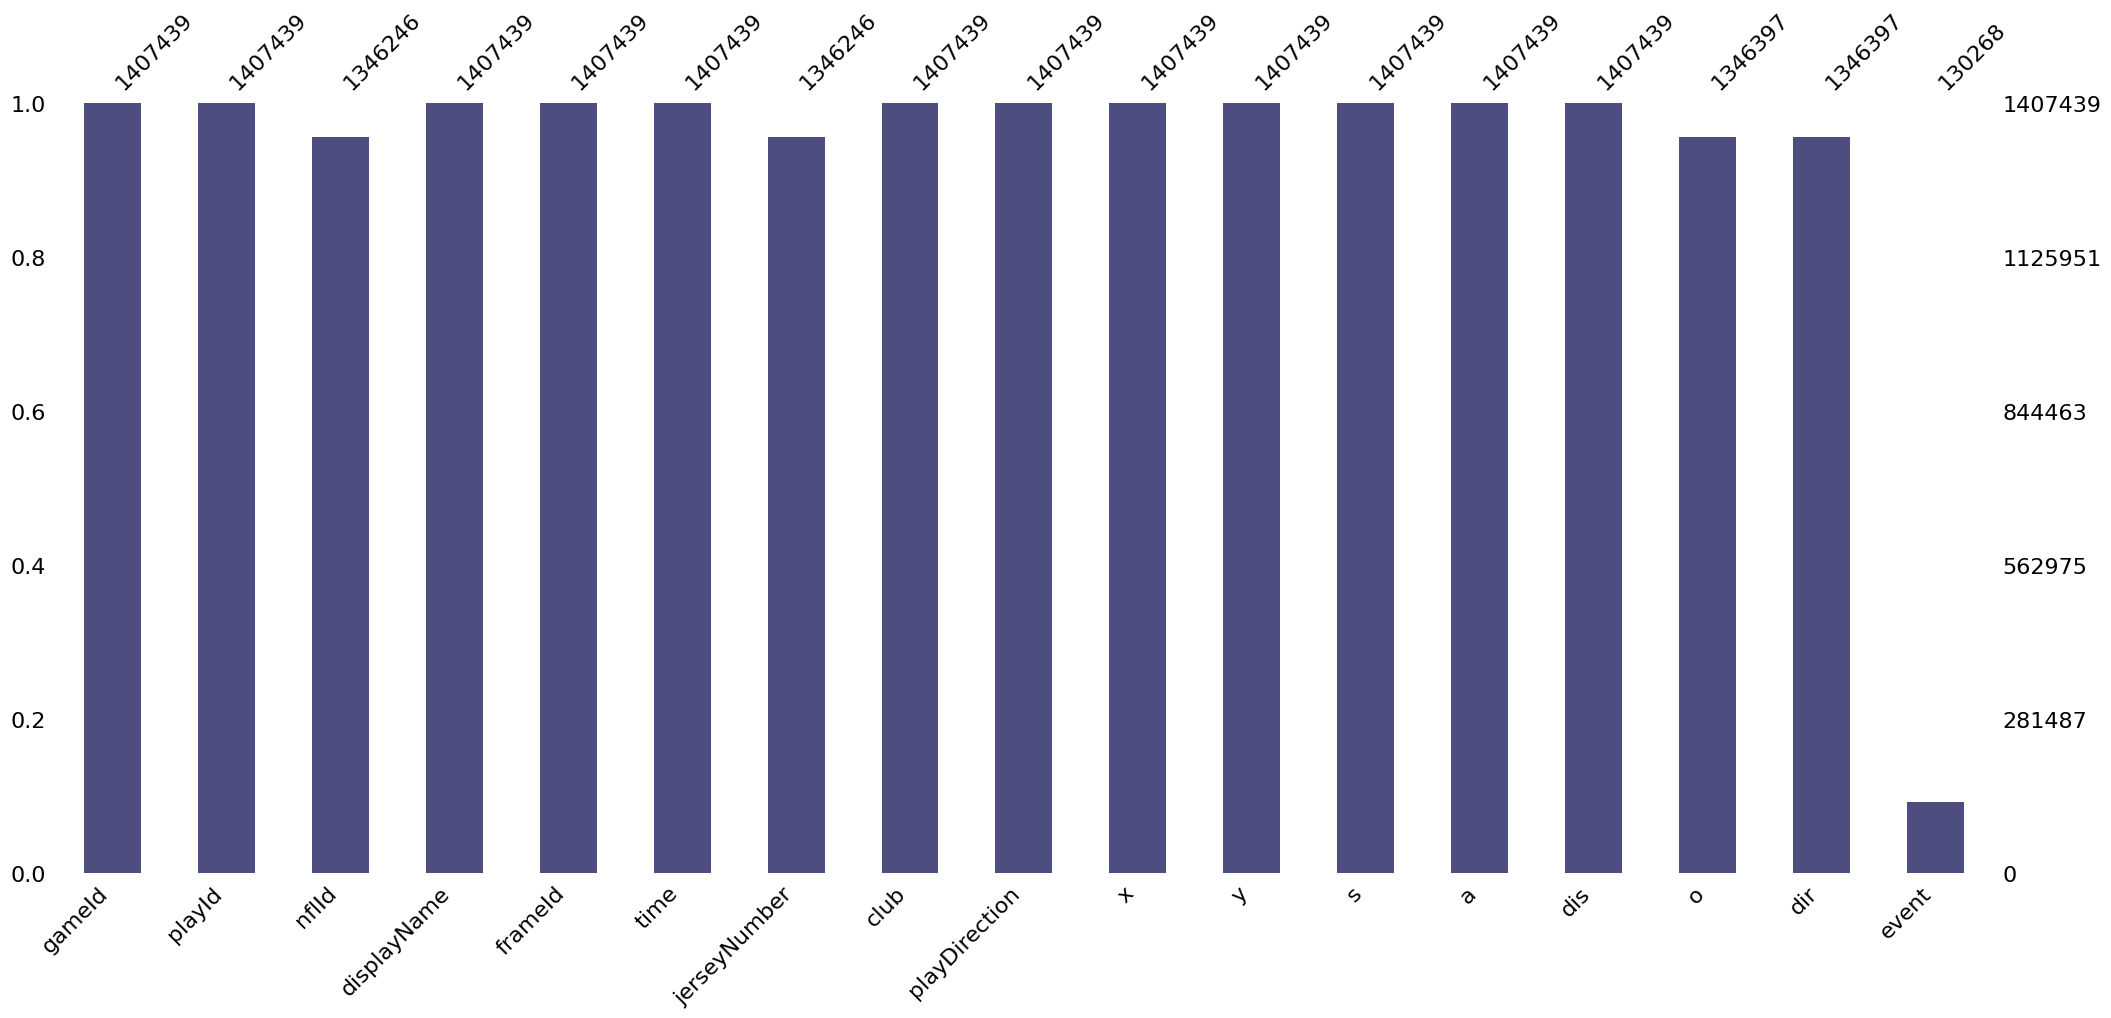

In [34]:
msno.bar(tr_week_1, color=(0.3,0.3,0.5))

<Axes: >

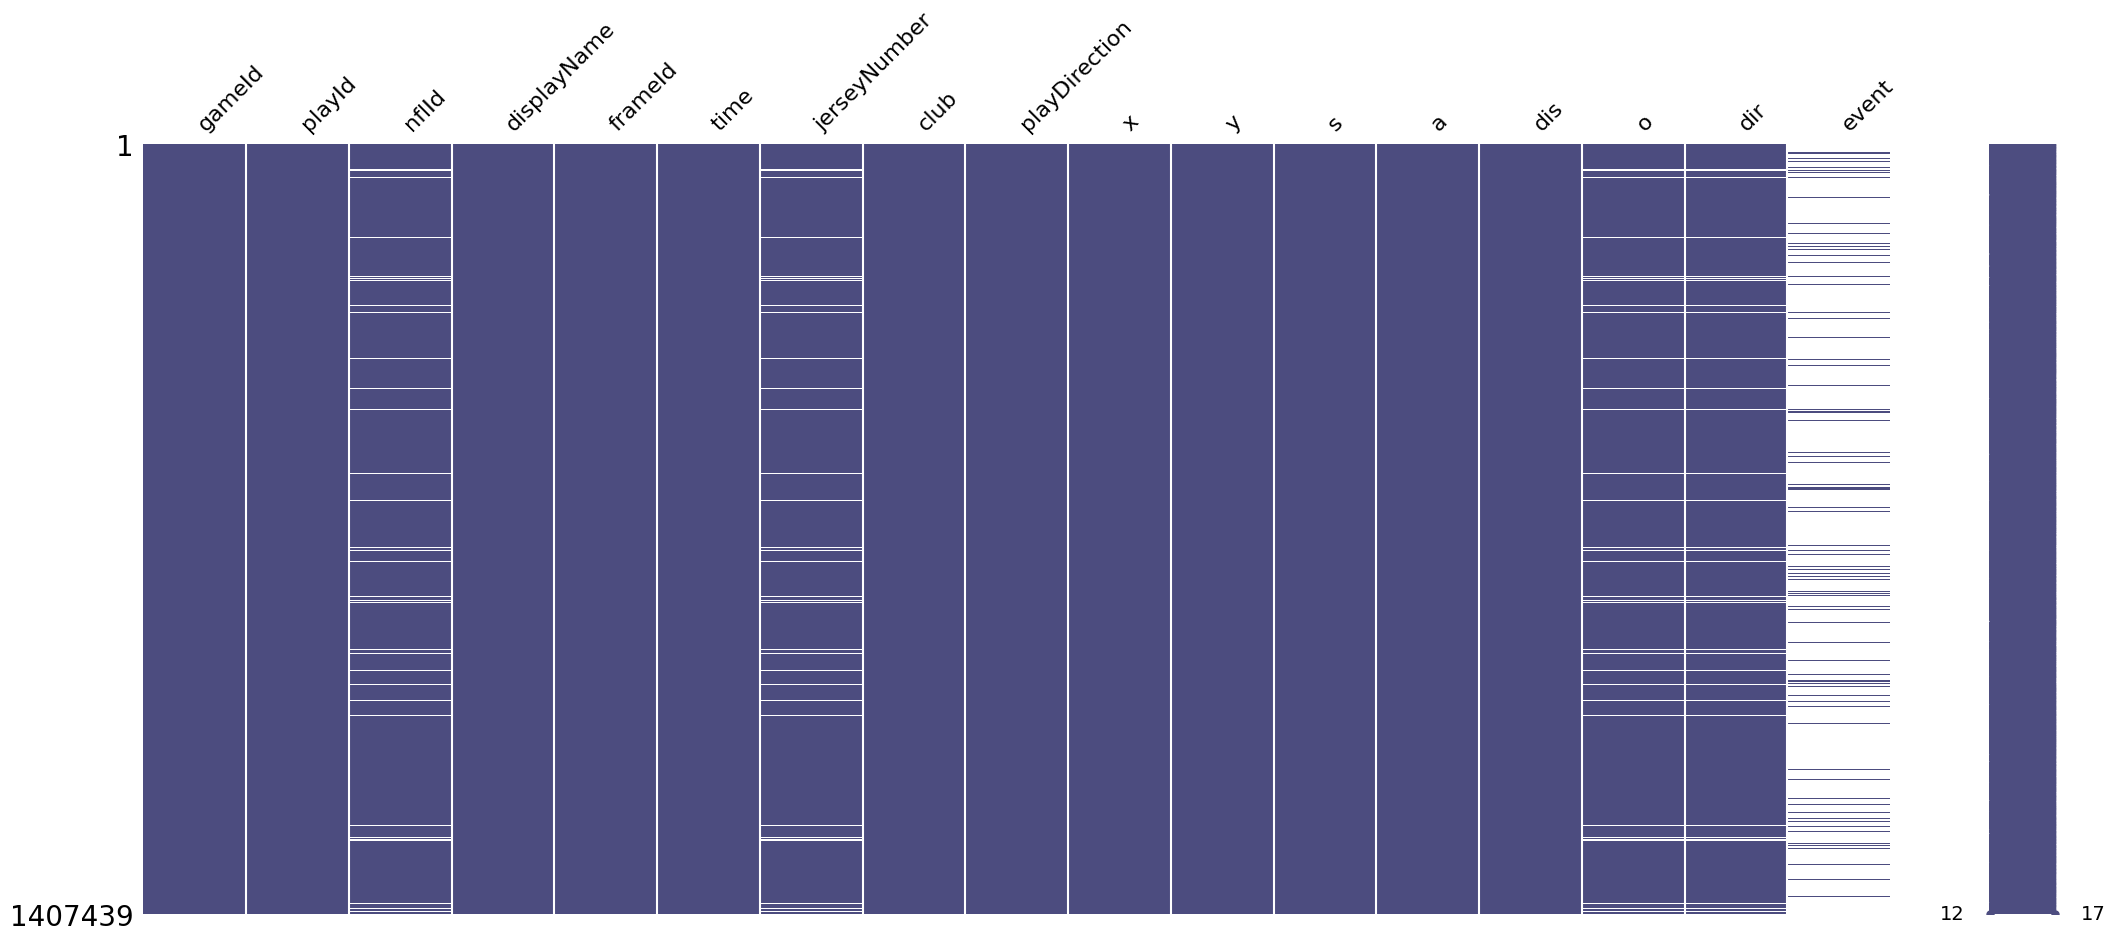

In [35]:
msno.matrix(tr_week_1, color=(0.3,0.3,0.5))

In [36]:
tr_week_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407439 entries, 0 to 1407438
Data columns (total 17 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   gameId         1407439 non-null  int64  
 1   playId         1407439 non-null  int64  
 2   nflId          1346246 non-null  float64
 3   displayName    1407439 non-null  object 
 4   frameId        1407439 non-null  int64  
 5   time           1407439 non-null  object 
 6   jerseyNumber   1346246 non-null  float64
 7   club           1407439 non-null  object 
 8   playDirection  1407439 non-null  object 
 9   x              1407439 non-null  float64
 10  y              1407439 non-null  float64
 11  s              1407439 non-null  float64
 12  a              1407439 non-null  float64
 13  dis            1407439 non-null  float64
 14  o              1346397 non-null  float64
 15  dir            1346397 non-null  float64
 16  event          130268 non-null   object 
dtypes: float

In [37]:
summarize_dataframe(tr_week_1).style.background_gradient(cmap='Purples')

,dtypes,missing#,missing%,uniques,first_value,last_value,count,min,max,mean
gameId,int64,0,0.000000,16,2022090800,2022091200,1407439,2022090800.000000,2022091200.000000,2022091094.552367
playId,int64,0,0.000000,1247,56,3826,1407439,55.000000,5096.000000,2030.071299
nflId,float64,6119300,4.347826,1171,35472.000000,nan,1346246,25511.000000,55173.000000,47241.911904
displayName,object,0,0.000000,1166,Rodger Saffold,football,1407439,nan,nan,nan
frameId,int64,0,0.000000,114,1,53,1407439,1.000000,114.000000,25.121795
time,object,0,0.000000,55516,2022-09-08 20:24:05.200000,2022-09-12 23:05:58.200000,1407439,nan,nan,nan
jerseyNumber,float64,6119300,4.347826,99,76.000000,nan,1346246,1.000000,99.000000,48.478239
club,object,0,0.000000,33,BUF,football,1407439,nan,nan,nan
playDirection,object,0,0.000000,2,left,left,1407439,nan,nan,nan
x,float64,0,0.000000,21453,88.370000,55.570000,1407439,-1.270000,120.160000,61.720514


In [38]:
del tr_week_1
# Returns the number of
# objects it has collected
# and deallocated
collected = gc.collect()
 
# Prints Garbage collector
# as 0 object
print("Garbage collector: collected",
          "%d objects." % collected)# Importing gc module

Garbage collector: collected 38 objects.


# Chapter 4: Insights from Games Data

In [ ]:
check = games['gameDate'].value_counts().reset_index()

check.columns = [
    'date', 
    'games'
]

check = check.sort_values('date')

fig = px.bar(
    check, 
    y='date', 
    x="games", 
    orientation='h', 
    color='date',
    title='Number of games by dates', 
    height=900, 
    width=800,
    color_discrete_sequence=px.colors.qualitative.Prism,
)
fig.show()